# No-validación tarifaria con CDR y Bip: método, hallazgos y límite de cobertura

## Resumen en una página

| | |
|---|---|
| Qué se medía | Tasa de no-validación por comuna frente a pobreza. Resultado: r = 0,33. |
| La alarma | Ese 0,33 no era significativo (p = 0,077) y los mapas no calzaban. |
| La intuición | El CDR registra desigual: en algunas comunas se observan menos pings. |
| Qué se probó | (1) descontar nº de usuarios, (2) usar solo usuarios bien cubiertos, (3) ajustar por densidad de antenas (SUBTEL). |
| Qué pasó | Las tres bajan o eliminan la correlación (0,15 / 0,08 / 0,26). |
| El problema | La tasa depende de la cobertura del CDR (r cercano a -0,48 con nº usuarios y pings, significativo), y la cobertura es menor en comunas de menores ingresos (r = -0,67). |
| La prueba | En una simulación sin diferencias reales de evasión, la cobertura sola produce una correlación de 0,39. |
| Conclusión | Con estos datos no se puede determinar si hay relación con el nivel socioeconómico: la cobertura está confundida con la pobreza. |

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

DATA = ROOT / 'data'
ev   = pd.read_parquet(DATA / 'evasion_por_comuna.parquet')
feat = pd.read_parquet(DATA / 'features_clasificados.parquet')
hog  = pd.read_parquet(DATA / 'hogar.parquet')[['user_id', 'comuna_gadm']]

ev['pobreza'] = ev['tasa_pobreza'].astype(float)
ev['tasa']    = ev['tasa_no_validacion'].astype(float)
ev['usuarios'] = ev['n_parece_transito']

_u = feat[['user_id','n_pings']].merge(hog, on='user_id').dropna(subset=['comuna_gadm'])
pings_com = _u.groupby('comuna_gadm')['n_pings'].median().reset_index(name='pings_med')
ev = ev.merge(pings_com, on='comuna_gadm', how='left')
print(f'{len(ev)} comunas en el análisis')

30 comunas en el análisis


## 1. Qué había antes

La propuesta original buscaba medir la evasión tarifaria y ver si era mayor en las comunas
de menores ingresos. El método: un usuario que en el CDR se mueve como pasajero de transporte pero sin
un registro de validación Bip consistente es candidato a no-validación. Se calculó una tasa
de no-validación por comuna y se cruzó con la tasa de pobreza (SAE 2022).

El primer resultado fue una correlación positiva entre pobreza y no-validación.

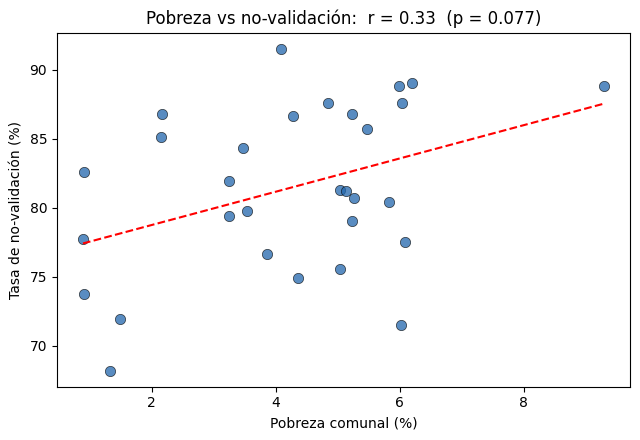

Correlación pobreza - no-validación: r = 0.328, p = 0.077


In [2]:
r1, p1 = stats.spearmanr(ev['pobreza'], ev['tasa'])
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.scatter(ev['pobreza']*100, ev['tasa']*100, s=55, color='#2166ac', alpha=0.75, edgecolors='k', linewidths=0.5)
m, b = np.polyfit(ev['pobreza'], ev['tasa'], 1)
xs = np.linspace(ev['pobreza'].min(), ev['pobreza'].max(), 50)
ax.plot(xs*100, (m*xs+b)*100, 'r--')
ax.set_xlabel('Pobreza comunal (%)'); ax.set_ylabel('Tasa de no-validación (%)')
ax.set_title(f'Pobreza vs no-validación:  r = {r1:.2f}  (p = {p1:.3f})')
plt.tight_layout(); plt.show()
print(f'Correlación pobreza - no-validación: r = {r1:.3f}, p = {p1:.3f}')

## 2. Cómo se detectó el problema

Dos señales:

1. El número no era significativo. Con 30 comunas, r = 0,33 tiene p = 0,077, sobre el umbral
   habitual de 0,05.
2. Los mapas no calzaban. En el análisis espacial (LISA) aparecían comunas en categorías que
   no correspondían a su nivel socioeconómico.

Por eso se decidió poner a prueba el 0,33 antes de usarlo.

## 3. La intuición: el CDR registra desigual

El CDR (Call Detail Records) deja un registro, un ping, cuando el celular tiene actividad en
la red: una llamada entrante o saliente, un mensaje, o uso de datos. Si el teléfono está sin
actividad no genera ping. Por eso la cantidad de pings depende de cuánto usa cada persona el
celular (Zhao et al., 2016; Ranjan et al., 2012).

La hipótesis: si en algunas comunas la gente aparece con menos pings, ahí se confirman menos
validadores y la no-validación se ve más alta sin que cambie el comportamiento. El origen de
esa diferencia de pings se discute en la sección 5.4.

## 4. Correcciones que se probaron

Criterio: si la relación con pobreza fuera real, debería sobrevivir al corregir el sesgo de
cobertura. Se probaron tres correcciones.

### 4.1 Descontar el número de usuarios (correlación parcial)

Recordatorio de qué son r y p:

- r mide qué tan fuerte es la relación, de -1 a 1. Cerca de 0 es casi sin relación, cerca de
  -1 o 1 es fuerte. El signo indica la dirección (positivo: suben juntas; negativo: una sube
  y la otra baja).
- p es la probabilidad de que esa relación aparezca por casualidad si en realidad no
  existiera. Con p bajo 0,05 se considera confiable. Con p más alto puede ser casualidad y no
  se considera significativa. Un p más alto significa menos significativo.

Pregunta: ¿queda relación entre pobreza y no-validación después de quitar el efecto del
número de usuarios de cada comuna?

In [3]:
def parcial(x, y, z):
    rx, ry, rz = stats.rankdata(x), stats.rankdata(y), stats.rankdata(z)
    rxy = np.corrcoef(rx, ry)[0,1]; rxz = np.corrcoef(rx, rz)[0,1]; ryz = np.corrcoef(ry, rz)[0,1]
    r = (rxy - rxz*ryz) / np.sqrt((1-rxz**2)*(1-ryz**2))
    n = len(x); t = r*np.sqrt((n-3)/(1-r**2)); p = 2*stats.t.sf(abs(t), n-3)
    return r, p

rA, pA = parcial(ev['pobreza'].values, ev['tasa'].values, ev['usuarios'].values)
print(f'Sin corregir:               r = {r1:+.2f}')
print(f'Descontando nº de usuarios: r = {rA:+.2f}  (p = {pA:.2f})')

Sin corregir:               r = +0.33
Descontando nº de usuarios: r = +0.15  (p = 0.44)


r bajó de 0,33 a 0,15 y p subió de 0,077 a 0,44. Al descontar la cobertura, lo que
queda se acerca a cero y tiene 44% de probabilidad de ser casualidad. La relación con pobreza
no resiste la corrección.

### 4.2 Usar solo usuarios bien cubiertos

Otra forma de quitar el sesgo: mirar solo a los usuarios con muchos pings, donde el CDR
funciona parejo en todas las comunas y no hay déficit de cobertura.

- Todos los usuarios: r = 0,33
- Solo usuarios con más de 1500 pings: r cercano a 0,08

Por qué baja r: el sesgo era que pocos pings inflan la no-validación. Al mirar solo a los bien
cubiertos, ese mecanismo ya no opera. Si la relación pobreza-evasión fuera real, seguiría
apareciendo, porque la conducta no depende de los pings. Desaparece (0,08), lo que indica que
la correlación venía del sesgo. El costo: al exigir muchos pings, en las comunas de menores ingresos queda
muy poca gente y deja de representarlas, por lo que esta vía sirve para probar el sesgo, no
para medir.

### 4.3 Ajustar por densidad de antenas (datos de SUBTEL)

Hipótesis: menos antenas implican menos oportunidades de ping. Se probó con el listado público
de estaciones base de SUBTEL, asignando cada antena a su comuna y midiendo densidad.

In [4]:
dens = pd.read_parquet(DATA / 'antenas' / 'densidad_antenas_comuna.parquet')
ua   = pd.read_parquet(DATA / 'antenas' / 'usuarios_antenas.parquet')
evd  = ev.merge(dens[['comuna_gadm','dens_sitios_km2']], on='comuna_gadm', how='left').dropna(subset=['dens_sitios_km2'])

r_ap, p_ap = stats.spearmanr(ua['n_antenas_2km'], ua['n_pings'])
rB, pB = parcial(evd['pobreza'].values, evd['tasa'].values, evd['dens_sitios_km2'].values)

print(f'antenas cerca del hogar vs pings (17k usuarios): r = {r_ap:+.2f} (p={p_ap:.0e})')
print(f'pobreza vs tasa, descontando densidad de antenas: r = {rB:+.2f} (p={pB:.2f})')

antenas cerca del hogar vs pings (17k usuarios): r = +0.09 (p=1e-31)
pobreza vs tasa, descontando densidad de antenas: r = +0.26 (p=0.18)


La relación entre antenas cercanas y pings existe pero es débil: pasar de 12 a 369
antenas cercanas sube los pings de un usuario típico de unos 800 a unos 1187. Al descontar la
densidad de antenas, la correlación con pobreza pasa de 0,33 a 0,26, casi sin cambio.

Ponderar por antenas no recupera la información faltante. Confirmar un validador requiere que
el celular coincida con la tarjeta Bip varios días, y con pocos pings hubo menos coincidencias
posibles. Ningún peso reconstruye una coincidencia que no se registró.

## 5. El problema de fondo: la tasa está confundida con la cobertura

Las secciones anteriores intentaban corregir. Esta muestra qué es el problema, con datos.

### 5.1 La tasa la determina la cobertura

In [5]:
filas = [
    ('nº usuarios', 'tasa',   *stats.spearmanr(ev['usuarios'], ev['tasa'])),
    ('pings/usuario','tasa',  *stats.spearmanr(ev['pings_med'], ev['tasa'])),
    ('pobreza',     'tasa',   *stats.spearmanr(ev['pobreza'],  ev['tasa'])),
    ('pobreza',     'pings',  *stats.spearmanr(ev['pobreza'],  ev['pings_med'])),
]
print(f"{'relación':24} {'r':>7} {'p':>8}   significativo")
for a,b,r,p in filas:
    sig = 'sí' if p < 0.05 else 'no'
    print(f'{a+" vs "+b:24} {r:+7.2f} {p:8.3f}   {sig}')

relación                       r        p   significativo
nº usuarios vs tasa        -0.47    0.009   sí
pings/usuario vs tasa      -0.49    0.006   sí
pobreza vs tasa            +0.33    0.077   no
pobreza vs pings           -0.59    0.001   sí


Cómo leer la tabla. Cada fila pregunta si dos variables se mueven juntas:

- nº usuarios vs tasa: r = -0,47, significativo. Donde hay más usuarios, la no-validación es
  más baja.
- pings/usuario vs tasa: r = -0,49, significativo. Más pings, menos no-validación.
- pobreza vs tasa: r = 0,33, no significativo. Es la relación que se quería medir y la única
  que no pasa la prueba de confianza.
- pobreza vs pings: r = -0,59, significativo. Las comunas de menores ingresos tienen menos pings.

Lo que mueve la tasa con confianza estadística es la cobertura. Como la cobertura va junto con
la pobreza, aparece un patrón socioeconómico que en realidad refleja la cobertura.

### 5.2 El mecanismo: confirmar un validador depende de los pings

Se toma a la población que se mueve como pasajero de transporte y se ordena en seis grupos
según cuántos pings tienen, de menos a más. Para cada grupo se mide qué fracción se logra
confirmar como validador.

In [6]:
pop = feat[feat['patron_similar']==True].merge(hog, on='user_id').dropna(subset=['comuna_gadm']).copy()
pop['confirmado'] = (pop['grupo']=='validador_consistente').astype(int)
pop['bin'] = pd.qcut(pop['n_pings'], 6, labels=False)
tab = pop.groupby('bin').agg(pings_mediana=('n_pings','median'), prob_confirmar=('confirmado','mean'))
print(tab.to_string())
print(f"\nspearman(pings, confirmado) = {stats.spearmanr(pop['n_pings'], pop['confirmado'])[0]:+.2f}")

     pings_mediana  prob_confirmar
bin                               
0            774.0        0.105724
1           1111.0        0.088315
2           1461.0        0.146739
3           1939.0        0.207177
4           2617.0        0.262695
5           4072.0        0.402712

spearman(pings, confirmado) = +0.26


La columna pings_mediana es cuántos pings tiene un usuario típico del grupo, y
prob_confirmar es la fracción del grupo que se logra confirmar como validador. El grupo con
menos pings (cerca de 774) se confirma en 10%, y el de más pings (cerca de 4072) en 40%.

Confirmar a alguien como validador exige que sus pings CDR coincidan con sus validaciones Bip
en varios días distintos. Con pocos pings hay menos coincidencias posibles, así que de un
validador real se confirman menos validaciones, y si no llega al umbral de días queda contado
como no-validador. No es que no pague: su validación Bip existe, pero el método no logra
enlazarla con su rastro CDR. Las comunas con poca cobertura, que son las de menores ingresos, acumulan
así no-validadores que no corresponden a conducta real.

### 5.3 Simulación sin diferencias reales de evasión

Para saber si el 0,33 indica evasión real o solo cobertura, se construye un escenario
controlado donde la respuesta se conoce de antemano. En este escenario la probabilidad de
confirmar a cada persona como validador depende únicamente de sus pings, ajustada con una
regresión que no usa pobreza ni comuna. Por construcción ninguna comuna evade distinto: la
única diferencia entre comunas es la cobertura.

Se repite 200 veces y en cada repetición se mide la correlación entre pobreza y la tasa
resultante. Si en este escenario, donde no hay diferencia real, igual aparece una correlación
cercana al 0,33 observado, entonces el 0,33 real no es evidencia de evasión: es lo que produce
la cobertura por sí sola.

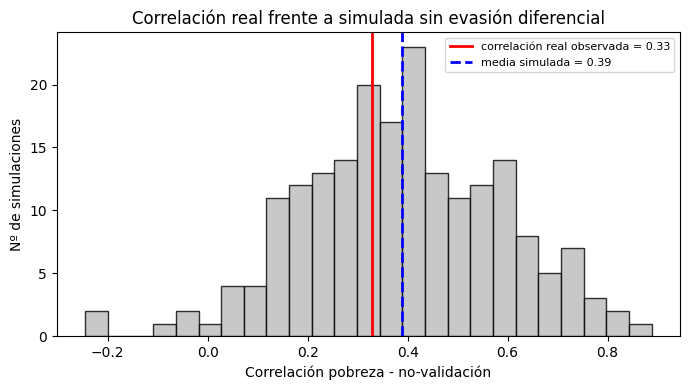

Real observada:              r = +0.33
Simulada (sin evasión real): r = +0.39  [+0.02, +0.76]
82% de las simulaciones dan r>=0,20 solo por cobertura


In [7]:
from sklearn.linear_model import LogisticRegression
rng = np.random.default_rng(42)

X = np.log10(pop[['n_pings']].values); y = pop['confirmado'].values
pop['p_hat'] = LogisticRegression().fit(X, y).predict_proba(X)[:,1]

sims = []
for _ in range(200):
    pop['conf_sim'] = (rng.random(len(pop)) < pop['p_hat']).astype(int)
    g = pop.groupby('comuna_gadm')['conf_sim'].agg(['mean','size'])
    g = g[g['size']>=200]
    d = (1-g['mean']).reset_index(name='tasa_sim').merge(ev[['comuna_gadm','pobreza']], on='comuna_gadm')
    sims.append(stats.spearmanr(d['tasa_sim'], d['pobreza'])[0])
sims = np.array(sims)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(sims, bins=25, color='#bbbbbb', edgecolor='k', alpha=0.8)
ax.axvline(r1, color='r', lw=2, label=f'correlación real observada = {r1:.2f}')
ax.axvline(sims.mean(), color='b', lw=2, ls='--', label=f'media simulada = {sims.mean():.2f}')
ax.set_xlabel('Correlación pobreza - no-validación'); ax.set_ylabel('Nº de simulaciones')
ax.set_title('Correlación real frente a simulada sin evasión diferencial')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print(f'Real observada:              r = {r1:+.2f}')
print(f'Simulada (sin evasión real): r = {sims.mean():+.2f}  [{np.percentile(sims,2.5):+.2f}, {np.percentile(sims,97.5):+.2f}]')
print(f'{100*(sims>=0.20).mean():.0f}% de las simulaciones dan r>=0,20 solo por cobertura')

Recordatorio: en el mundo simulado nadie evade distinto según su comuna; lo único que
cambia entre comunas son los pings (la cobertura). Si aun así aparece correlación con pobreza,
esa correlación viene solo de la cobertura.

Lo que se observa:

- En los datos reales, la correlación entre pobreza y no-validación es 0,33 (la línea roja).
- En el mundo simulado, sin ninguna diferencia real de evasión, esa correlación sale 0,39 en
  promedio, y en el 82% de las 200 simulaciones es 0,20 o más. Es decir, un mundo donde nadie
  evade distinto igual produce una correlación parecida, o más grande, que la real.
- Por eso el 0,33 real no destaca: cae justo dentro de lo que genera la pura cobertura, y de
  hecho es menor que el promedio simulado.

Qué se concluye:

El 0,33 observado pudo salir entero del sesgo de cobertura, sin que exista ninguna diferencia
real de evasión entre comunas. Por eso ese número no sirve como evidencia de que en las comunas
de menores ingresos se evada más, y no permite afirmar que exista una relación entre
no-validación y nivel socioeconómico.

### 5.4 Origen de la diferencia de cobertura

La menor cobertura del CDR en las comunas de menores ingresos no se mide en esta tesis. Queda como un
conjunto de causas posibles, documentadas en la literatura:

- Datos de un solo operador. El CDR proviene de una sola compañía, y la base de clientes de un
  operador es un subconjunto no aleatorio de la población, sesgado por preferencia de operador;
  esa representatividad no crece de forma proporcional a la participación de mercado (Ricciato
  et al., 2017; Wesolowski et al., 2013).
- Intensidad de uso. El ping se genera al usar el teléfono, así que quien lo usa menos deja
  menos pings; el CDR es un muestreo por evento, disperso y dependiente de la actividad del
  usuario (Zhao et al., 2016; Ranjan et al., 2012).
- Modalidad de pago del servicio móvil. El prepago, más frecuente entre los usuarios sensibles
  al precio en la región, se asocia a menor actividad registrada (GSMA; Banco Mundial).

Para la conclusión no se necesita saber cuál causa pesa más: basta con que la cobertura mueve
la tasa y la cobertura va junto con la pobreza, ambos medidos.

### 5.5 El sesgo también afecta al clasificador

El clasificador alcanza un F1 cercano a 0,92, pero varias de sus features crecen con la
cobertura (n_pings, n_dias_activos, n_paraderos_distintos). Para ver cuánto de ese desempeño
viene de la cobertura y no de la conducta, se compara el clasificador con tres conjuntos de
features: el actual, uno robusto a cobertura (fracciones y métricas normalizadas: frac_cerca,
frac_manana, frac_tarde, paraderos por día, radio de giro y entropía de ubicaciones) y la
combinación de ambos.

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_validate

mob = pd.read_parquet(DATA / 'features_mobilidad.parquet')
cl = feat.merge(mob, on='user_id', how='left')
cl['paraderos_por_dia'] = cl['n_paraderos_distintos'] / cl['n_dias_activos'].clip(lower=1)
ent_cl = cl[cl['grupo'].isin(['validador_consistente','sin_uso_aparente'])].copy()
y_cl = (ent_cl['grupo']=='validador_consistente').astype(int).values

ACTUAL = ['n_pings','n_dias_activos','frac_cerca_paradero','n_paraderos_distintos','frac_manana','frac_tarde']
ROBUST = ['frac_cerca_paradero','frac_manana','frac_tarde','paraderos_por_dia','radio_giro','entropia_ubic']

def f1_cv(cols):
    X = SimpleImputer(strategy='median').fit_transform(ent_cl[cols].values)
    m = RandomForestClassifier(n_estimators=300, max_depth=12, class_weight='balanced', random_state=42)
    kf = StratifiedKFold(5, shuffle=True, random_state=42)
    return cross_validate(m, X, y_cl, cv=kf, scoring=['f1'])['test_f1'].mean()

print(f"actual (con volumen):  F1 = {f1_cv(ACTUAL):.3f}")
print(f"robusto a cobertura:   F1 = {f1_cv(ROBUST):.3f}")
print(f"combinado:             F1 = {f1_cv(ACTUAL+['radio_giro','entropia_ubic','paraderos_por_dia']):.3f}")

actual (con volumen):  F1 = 0.924


robusto a cobertura:   F1 = 0.762


combinado:             F1 = 0.924


Con las features actuales el F1 es 0,92. Con solo features robustas a cobertura baja a
0,76, y combinarlas no supera al actual. Parte del desempeño del clasificador proviene del
volumen de datos, no solo de la conducta de transporte. El sesgo de cobertura, además de
afectar la asociación con pobreza, infla el rendimiento aparente del clasificador. Es una
limitación adicional del método.

## 6. Conclusión

No se concluye que no exista relación entre evasión y pobreza, porque eso no se puede saber
con estos datos. Se concluye lo siguiente:

Con CDR de un operador y Bip no se puede determinar la dimensión socioeconómica de la
no-validación, porque la cobertura del CDR está confundida con el nivel socioeconómico: la
tasa de no-validación depende de la cobertura y la cobertura es menor en las comunas de menores
ingresos.

Dos términos para nombrar esto:

- Artefacto: un resultado que aparece por cómo se mide (un sesgo o defecto del método), no por
  el fenómeno real que se estudia. La correlación con pobreza es un artefacto: la produce el
  sesgo de cobertura del CDR, no una diferencia real de evasión.
- Variable confusora (confounding): una tercera variable que afecta a las dos que se comparan y
  crea una asociación falsa entre ellas. Aquí la confusora es la cobertura: afecta a la tasa de
  no-validación y va junto con la pobreza, así que inventa una correlación entre ambas.

Identificar que un efecto aparente proviene de una confusión es un resultado de validez.

## Referencias

- Zhao, Z., Shaw, S.-L., Xu, Y., Lu, F., Chen, J., Yin, L. (2016). Understanding the bias of
  call detail records in human mobility research. International Journal of Geographical
  Information Science.
- Ranjan, G., Zang, H., Zhang, Z.-L., Bolot, J. (2012). Are call detail records biased for
  sampling human mobility? ACM SIGMOBILE Mobile Computing and Communications Review.
- Wesolowski, A., et al. (2013). The impact of biases in mobile phone ownership on estimates
  of human mobility. Journal of the Royal Society Interface.
- Ricciato, F., et al. (2017). Beyond the single-operator, CDR-only paradigm. Pervasive and
  Mobile Computing.
- Ferres, L., Gauvin, L. (2026). Correcting socioeconomic bias in mobile phone mobility
  estimates using multilevel regression and poststratification. arXiv:2604.16193.
- SUBTEL (2023). Informe del Sector Telecomunicaciones, diciembre 2023. 133 líneas móviles por
  cada 100 habitantes.
- SUBTEL (2023). Encuesta de Acceso y Usos de Internet.
- GSMA y Banco Mundial, reportes sobre predominancia del prepago en poblaciones sensibles al
  precio. Can the poor afford mobile telephony? Evidence from Latin America, Telecommunications
  Policy.
- Ministerio de Desarrollo Social (SAE 2022). Tasa de pobreza por ingresos por comuna.